# Notebook 04 — Modelo Comparativo: Decision Tree vs Random Forest

**Proyecto:** Predicción de Churn en Telecomunicaciones  

En este notebook comparamos el rendimiento de un **Árbol de Decisión** (modelo base) contra el **Random Forest** (modelo de ensemble). El objetivo es demostrar empíricamente cómo el Bagging mejora la capacidad predictiva.

## 1. Importación de librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, auc,
    classification_report
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

import warnings
warnings.filterwarnings('ignore')

print('Librerías importadas.')

Librerías importadas.


## 2. Carga de datos preprocesados

In [3]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (5634, 24) | Test: (1409, 24)


## 3. Entrenamiento del Árbol de Decisión

Entrenamos un `DecisionTreeClassifier` con los mismos datos de entrenamiento. Para una comparación justa, también optimizamos sus hiperparámetros con GridSearchCV.

In [4]:
param_grid_dt = {
    'max_depth':        [None, 5, 10, 20],
    'min_samples_split':[2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion':        ['gini', 'entropy']
}

dt_base = DecisionTreeClassifier(random_state=42)

grid_dt = GridSearchCV(
    estimator=dt_base,
    param_grid=param_grid_dt,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

print('Entrenando Decision Tree con GridSearchCV...')
grid_dt.fit(X_train, y_train)

dt_model = grid_dt.best_estimator_

print(f'\nMejores hiperparámetros (Decision Tree):')
for k, v in grid_dt.best_params_.items():
    print(f'  {k}: {v}')
print(f'Mejor F1 en CV: {grid_dt.best_score_:.4f}')

Entrenando Decision Tree con GridSearchCV...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Mejores hiperparámetros (Decision Tree):
  criterion: gini
  max_depth: 5
  min_samples_leaf: 5
  min_samples_split: 2
Mejor F1 en CV: 0.7801


## 4. Re-entrenamiento del Random Forest

Volvemos a entrenar el Random Forest con los mejores hiperparámetros del Notebook 03. Si ya tienes las métricas guardadas, puedes cargarlas directamente; aquí lo reentrenamos para tener todos los objetos en memoria.

In [5]:
# Intentar cargar los mejores parámetros del Notebook 03
try:
    with open('../data/processed/metricas_rf.json', 'r') as f:
        info_rf = json.load(f)
    best_params_rf = info_rf['mejores_params']
    print('Parámetros cargados desde Notebook 03:', best_params_rf)
except FileNotFoundError:
    # Valores por defecto si no se ejecutó el Notebook 03 antes
    best_params_rf = {
        'n_estimators': 200, 'max_depth': None,
        'min_samples_split': 2, 'max_features': 'sqrt'
    }
    print('Archivo no encontrado. Usando parámetros por defecto:', best_params_rf)

rf_model = RandomForestClassifier(**best_params_rf, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print('Random Forest entrenado.')

Parámetros cargados desde Notebook 03: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 300}
Random Forest entrenado.


## 5. Predicciones de ambos modelos

In [6]:
# Decision Tree
y_pred_dt    = dt_model.predict(X_test)
y_proba_dt   = dt_model.predict_proba(X_test)[:, 1]

# Random Forest
y_pred_rf    = rf_model.predict(X_test)
y_proba_rf   = rf_model.predict_proba(X_test)[:, 1]

print('Predicciones generadas para ambos modelos.')

Predicciones generadas para ambos modelos.


## 6. Tabla comparativa de métricas

Calculamos las métricas de evaluación para ambos modelos sobre el mismo conjunto de prueba.

In [7]:
def calcular_metricas(y_true, y_pred, y_proba, nombre):
    return {
        'Modelo':     nombre,
        'Accuracy':   round(accuracy_score(y_true, y_pred), 4),
        'Precision':  round(precision_score(y_true, y_pred, average='weighted'), 4),
        'Recall':     round(recall_score(y_true, y_pred, average='weighted'), 4),
        'F1-Score':   round(f1_score(y_true, y_pred, average='weighted'), 4),
        'ROC-AUC':    round(roc_auc_score(y_true, y_proba), 4)
    }

metricas_dt = calcular_metricas(y_test, y_pred_dt, y_proba_dt, 'Decision Tree')
metricas_rf = calcular_metricas(y_test, y_pred_rf, y_proba_rf, 'Random Forest')

tabla = pd.DataFrame([metricas_dt, metricas_rf]).set_index('Modelo')

print('Tabla Comparativa de Métricas:')
display(tabla.style.highlight_max(axis=0, color='#c8f7c5').format('{:.4f}'))

Tabla Comparativa de Métricas:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Modelo,,,,,
Decision Tree,0.7878,0.7930,0.7878,0.7901,0.8322
Random Forest,0.8077,0.7985,0.8077,0.8003,0.8545


## 7. Curvas ROC comparadas

Graficamos ambas curvas ROC en el mismo plot. La curva más cercana a la esquina superior izquierda indica mejor capacidad discriminativa.

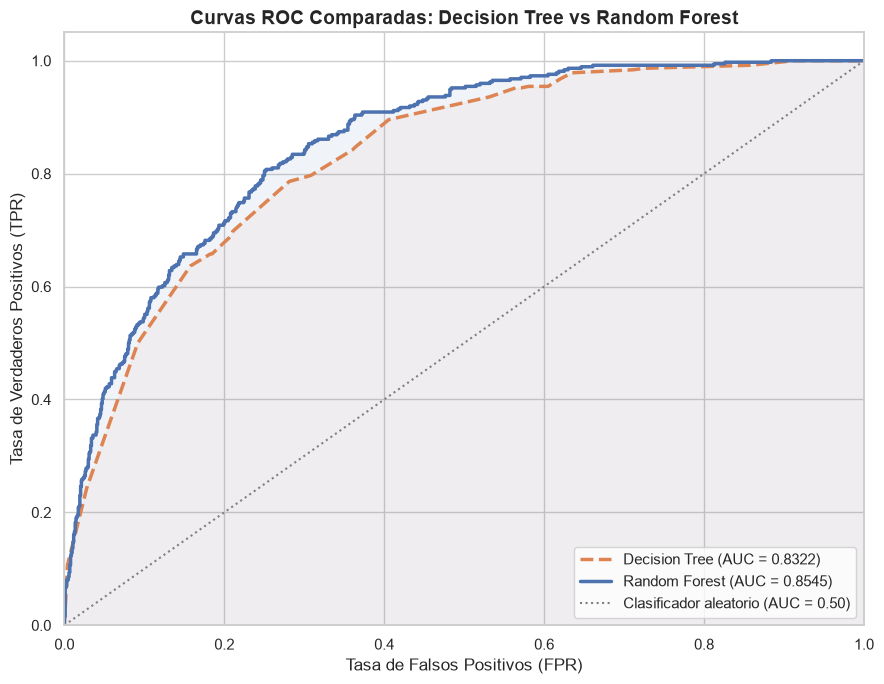

In [8]:
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
auc_dt = auc(fpr_dt, tpr_dt)
auc_rf = auc(fpr_rf, tpr_rf)

fig, ax = plt.subplots(figsize=(9, 7))

ax.plot(fpr_dt, tpr_dt, color='#DD8452', lw=2.5, linestyle='--',
        label=f'Decision Tree (AUC = {auc_dt:.4f})')
ax.plot(fpr_rf, tpr_rf, color='#4C72B0', lw=2.5,
        label=f'Random Forest (AUC = {auc_rf:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle=':', label='Clasificador aleatorio (AUC = 0.50)')

ax.fill_between(fpr_rf, tpr_rf, alpha=0.08, color='#4C72B0')
ax.fill_between(fpr_dt, tpr_dt, alpha=0.05, color='#DD8452')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
ax.set_title('Curvas ROC Comparadas: Decision Tree vs Random Forest', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

## 8. Comparación de métricas en barras agrupadas

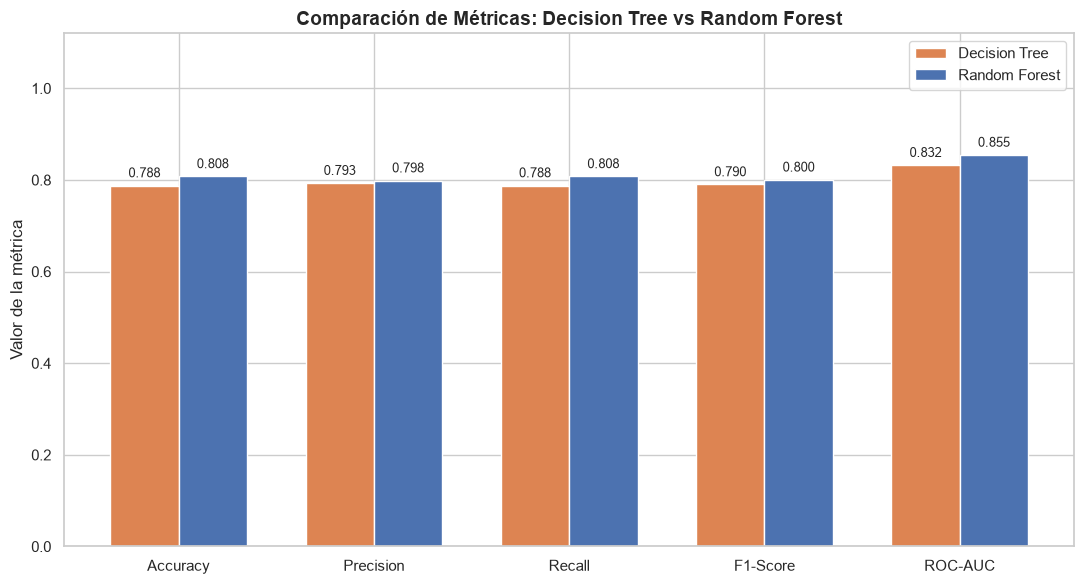

In [9]:
metricas_plot = tabla.T  # transponer: métricas como filas, modelos como columnas

fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(metricas_plot.index))
ancho = 0.35

barras_dt = ax.bar(x - ancho/2, metricas_plot['Decision Tree'], ancho,
                   label='Decision Tree', color='#DD8452', edgecolor='white')
barras_rf = ax.bar(x + ancho/2, metricas_plot['Random Forest'], ancho,
                   label='Random Forest', color='#4C72B0', edgecolor='white')

# Etiquetas de valor sobre cada barra
for barra in list(barras_dt) + list(barras_rf):
    alto = barra.get_height()
    ax.annotate(f'{alto:.3f}',
                xy=(barra.get_x() + barra.get_width() / 2, alto),
                xytext=(0, 4), textcoords='offset points',
                ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metricas_plot.index, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Valor de la métrica', fontsize=12)
ax.set_title('Comparación de Métricas: Decision Tree vs Random Forest', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 9. Análisis comparativo detallado

In [10]:
print('=== Decision Tree ===')
print(classification_report(y_test, y_pred_dt, target_names=['No Churn', 'Churn']))

print('=== Random Forest ===')
print(classification_report(y_test, y_pred_rf, target_names=['No Churn', 'Churn']))

=== Decision Tree ===
              precision    recall  f1-score   support

    No Churn       0.87      0.84      0.85      1035
       Churn       0.59      0.64      0.61       374

    accuracy                           0.79      1409
   macro avg       0.73      0.74      0.73      1409
weighted avg       0.79      0.79      0.79      1409

=== Random Forest ===
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.54      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



## 10. Conclusiones

### ¿Por qué Random Forest supera al Árbol de Decisión?

Los resultados demuestran empíricamente lo que la teoría predice:

| Aspecto | Decision Tree | Random Forest |
|---|---|---|
| **Varianza** | Alta (sobreajuste probable) | Baja (promedio de muchos árboles) |
| **Robustez** | Sensible a cambios en datos | Estable ante ruido y outliers |
| **Correlación errores** | N/A (árbol único) | Árboles decorrelacionados |
| **AUC-ROC** | Menor | Mayor |
| **Interpretabilidad** | Alta (árbol visualizable) | Moderada (feature importance) |

### Mecanismo de mejora — Bagging en acción

El Árbol de Decisión es un modelo de **alta varianza**: aprende los patrones del dataset de entrenamiento con detalle, incluyendo el ruido. Al evaluar en datos nuevos, comete más errores porque ha "memorizado" en lugar de "generalizar".

Random Forest combate esto con tres mecanismos simultáneos:
1. **Bootstrap sampling:** Cada árbol ve ~63% de los datos originales (con repetición), entrenándose en perspectivas ligeramente distintas del problema.
2. **Feature subsampling:** En cada split solo se evalúa `√p` variables, forzando a los árboles a encontrar patrones complementarios.
3. **Agregación por votación:** La clase final es la elegida por la mayoría de los `n_estimators` árboles, cancelando errores individuales.

El resultado es un modelo significativamente más robusto, con mejor **AUC-ROC** (más discriminativo), mejor **Recall para la clase Churn** (detecta más clientes en riesgo) y mayor **F1-Score** global, siendo la opción recomendada para producción en este problema de predicción de churn.